In [1]:
import os
import urllib.request
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt

# DOWNLOAD

In [8]:
# 1 - SETUP THE PATH

# Indiana Pines
indian_pines = 'indian_pines'
url_indian_pines_data = 'http://www.ehu.eus/ccwintco/uploads/6/67/Indian_pines_corrected.mat'
url_indian_pines_gt = 'http://www.ehu.eus/ccwintco/uploads/c/c4/Indian_pines_gt.mat'
path_name_indian_pines_data = "indian_pines_corrected.mat"
path_name_indian_pines_gt = "indian_pines_gt.mat"

# Salinas Valley
salinas_valley = 'salinas_valley'
url_salinas_valley_data = 'http://www.ehu.eus/ccwintco/uploads/a/a3/Salinas_corrected.mat'
url_salinas_valley_gt = 'http://www.ehu.eus/ccwintco/uploads/f/fa/Salinas_gt.mat'
path_name_salinas_valley_data = "salinas_valley_corrected.mat"
path_name_salinas_valley_gt = "salinas_valley_gt.mat"


main_path = os.path.join("..", "ds")
folder_name_indian_pines = os.path.join(main_path, indian_pines)
folder_name_salinas_valley = os.path.join(main_path, salinas_valley)

if not os.path.exists(folder_name_indian_pines):
    os.makedirs(folder_name_indian_pines)
    print(f"Directory structure '{folder_name_indian_pines}' created.")
if not os.path.exists(folder_name_salinas_valley):
    os.makedirs(folder_name_salinas_valley)
    print(f"Directory structure '{folder_name_salinas_valley}' created.")


# Download resources with GET request
def download_file(url, folder, filename):
    filepath = os.path.join(folder, filename)
    
    # Adding a User-Agent header because some university servers block blank requests
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    
    if not os.path.exists(filepath):
        print(f"Downloading {filename} into {folder}/...")
        with urllib.request.urlopen(req) as response, open(filepath, 'wb') as out_file:
            out_file.write(response.read())
        print("Done.")
    else:
        print(f"{filename} already exists in {folder}/.")
    return filepath


# URLs
path_data = download_file(url_indian_pines_data, folder_name_indian_pines, path_name_indian_pines_data)
path_gt = download_file(url_indian_pines_gt, folder_name_indian_pines, path_name_indian_pines_gt)

path_data = download_file(url_salinas_valley_data, folder_name_salinas_valley, path_name_salinas_valley_data)
path_gt = download_file(url_salinas_valley_gt, folder_name_salinas_valley, path_name_salinas_valley_gt)

Directory structure '../ds/indian_pines' created.
Directory structure '../ds/salinas_valley' created.
Done.
Done.
Done.
Done.


In [4]:
# 2 - LOAD THE DATA


main_path = os.path.join("..", "ds")

data_path = os.path.join(main_path, 'salinas_valley/salinas_valley_corrected.mat')
gt_path = os.path.join(main_path, 'salinas_valley/salinas_valley_gt.mat')

data = sio.loadmat(data_path)['salinas_corrected']
gt = sio.loadmat(gt_path)['salinas_gt']

print(f"Data Shape: {data.shape}")       # (145, 145, 200)
print(f"Ground Truth Shape: {gt.shape}") # (145, 145)

Data Shape: (512, 217, 204)
Ground Truth Shape: (512, 217)


In [5]:
# DISPLAY

# This cell maps the bandwidth to RGB channels in order to be displayed

# choosing bands 40, 25 and 10 to be mapped repsctively to channels Red, Green and Blue

# 40: Near infrared -> mapped to Red    ~780nm
# 25: Red light -> mapped to Green      ~640nm
# 10: Green light ->mapped to Blue      ~490nm

rgb_bands = [40, 25, 10]

# data[:, :, rgb_bands] mean select all the X and Y elements (all the pixels) and then select only those 3 bands
false_color = data[:, :, rgb_bands].astype(float)


# This for scales all the values between 0 and 1 (needed to be used for matplot lib)
for i in range(3):
    band_min = np.min(false_color[:,:,i])
    band_max = np.max(false_color[:,:,i])
    false_color[:,:,i] = (false_color[:,:,i] - band_min) / (band_max - band_min)

# ANALYSIS

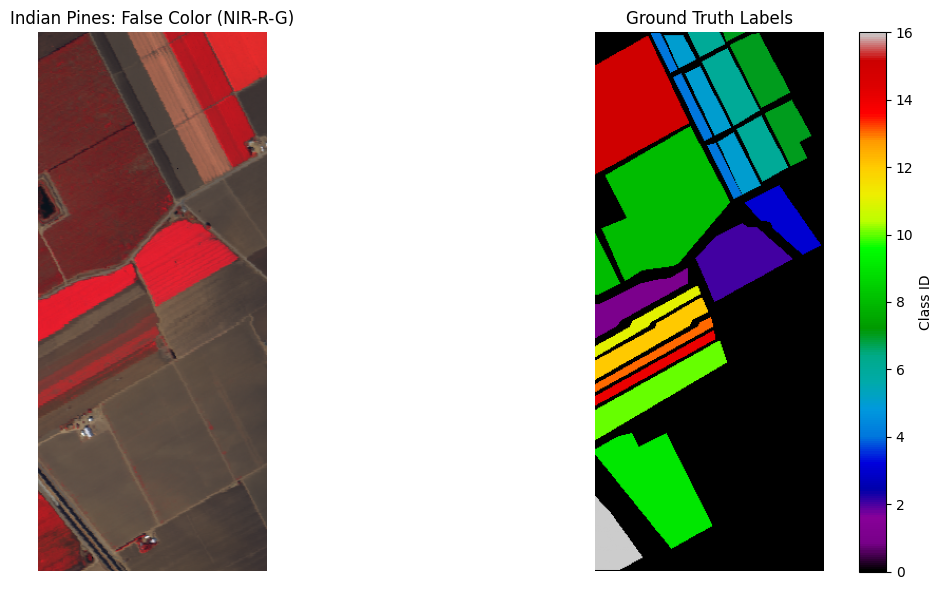

In [6]:
# --- 4. Plotting Results ---
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(false_color)
ax[0].set_title("Indian Pines: False Color (NIR-R-G)")
ax[0].axis('off')

img_gt = ax[1].imshow(gt, cmap='nipy_spectral')
ax[1].set_title("Ground Truth Labels")
ax[1].axis('off')

plt.colorbar(img_gt, ax=ax[1], label='Class ID')
plt.tight_layout()
plt.show()

**Left image**
- Bright red areas: These are areas with dense, healthy vegetation (like woods or fully grown crops). Plant leaves reflect massive amounts of NIR light, which is why they light up red here.
- Grey/greenish areas: These are likely bare soil, harvested fields, or fields where crops are still very small. Without large leaves to reflect the NIR light, they have a poor color.
- lines: there are some straigh and diagonal lines between fields, which are probably roads or railways.

**Right image**
This image represent the labels for each pixel (1 label - 1 color).
- The black areas represent unlabeled pixels becuase maybe they contain a woods or parts that are not lands destined to crop farming.
- Each distinct color corresponds to a specific type of crop or land cover

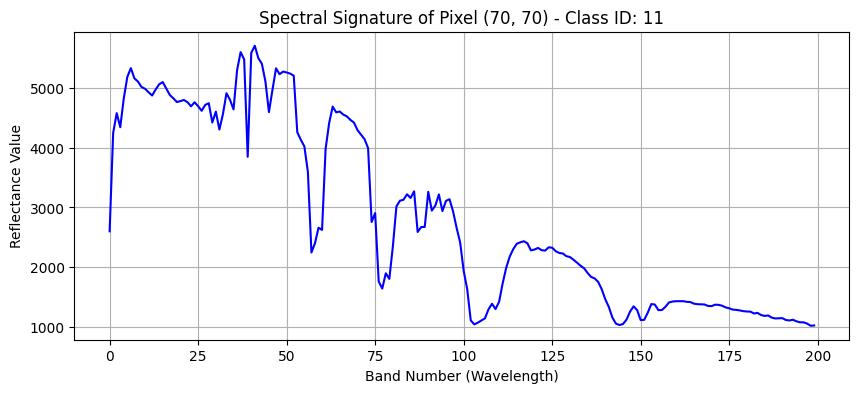

In [6]:
# --- 5. Spectral Signature Exploration ---
pixel_x, pixel_y = 70, 70 

plt.figure(figsize=(10, 4))
spectral_signature = data[pixel_x, pixel_y, :]
plt.plot(spectral_signature, color='blue', linewidth=1.5)
plt.title(f"Spectral Signature of Pixel ({pixel_x}, {pixel_y}) - Class ID: {gt[pixel_x, pixel_y]}")
plt.xlabel("Band Number (Wavelength)")
plt.ylabel("Reflectance Value")
plt.grid(True)
plt.show()

**X-axis** represents the 200 different channels (colors/wavelengths) the sensor captured, ranging from visible light (band 0) to shortwave infrared (band 200)

**Y-axis** tells how much sunlight bounced off the soybean field and hit the airplane's sensor.
- A high value (like 5000) means the plant acts like a mirror for that specific wavelength.
- A low value (like 1000) means the plant (or the atmosphere) absorbed the light, so very little bounced back.

**Analysis:** 
- **bands 0-50:** this range covers. visible light and Near-Infrared (NIR). Healthy plants absorb red and blue light for photosynthesis but reflect green. plants reflect massive ammounts of NIR light.
- **around band 55, 80 and 105:** Here there are some drops. These are the **Water absorption bands**. The light in these bands is completely absorbed by water moleculs in crops and the air between the airplane and the ground.
- **bands 125-200:** These bands cover the shortwave region, where the light it's almost all captured and barely reflected.

*NOTE:*
- visible light : $400$–$700\ nm$
- NIR : $700$–$1,100\ nm$
- SWIR : $1,100$–$2,500\ nm$

*Taxonomy:*
- NIR: Near infrared
- SWIR: SHort wave infreared

# Apply PCA

In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import torch

In [8]:
# Load the Data
main_path = os.path.join("..", "ds")

data_path = os.path.join(main_path, 'indiana_pines/indian_pines_corrected.mat')
gt_path = os.path.join(main_path, 'indiana_pines/indian_pines_gt.mat')

data = sio.loadmat(data_path)['indian_pines_corrected']
gt = sio.loadmat(gt_path)['indian_pines_gt']

# Reshape data for PCA
# PCA requires a 2D matrix (Samples x Features), not a 3D image cube.
# we flatten the 145x145 spatial grid into 21,025 individual pixel samples.
h, w, c = data.shape
data_2d = data.reshape(-1, c) # Shape becomes (21025, 200)

# Standardize the data.
# Hyperspectral bands can have wildly different numeric ranges. 
# We scale them so they all have a mean of 0 and variance of 1.
scaler = StandardScaler()
data_2d_scaled = scaler.fit_transform(data_2d)

# Fit PCA to check Variance (For your TA)
pca_full = PCA()
pca_full.fit(data_2d_scaled)

# Calculate cumulative variance (how much info we keep as we add components)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

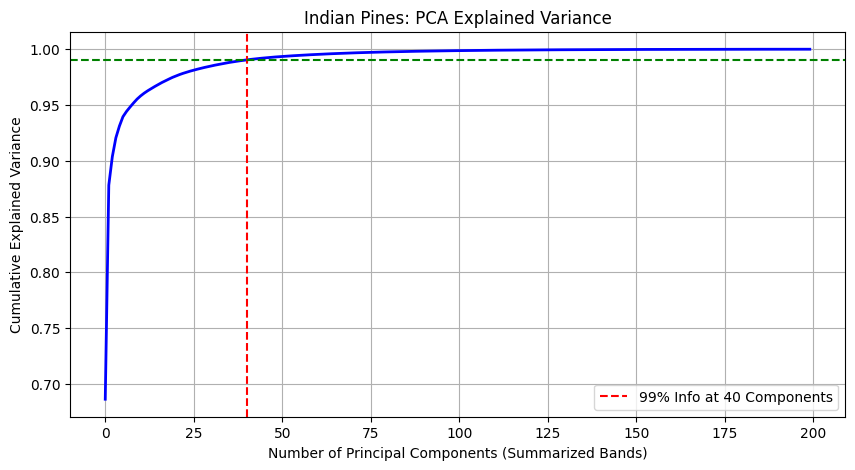

In [9]:
# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(cumulative_variance, linewidth=2, color='blue')
plt.xlabel('Number of Principal Components (Summarized Bands)')
plt.ylabel('Cumulative Explained Variance')
plt.title('Indian Pines: PCA Explained Variance')
plt.grid(True)

# Let's draw lines to see where we hit 99% of the original information
components_99 = np.argmax(cumulative_variance >= 0.99) + 1
plt.axvline(x=components_99, color='red', linestyle='--', label=f'99% Info at {components_99} Components')
plt.axhline(y=0.99, color='green', linestyle='--')
plt.legend()
plt.show()

# Apply the reduction.
# Based on the plot, we usually only need around 30 components.
n_components = 30
pca_reduced = PCA(n_components=n_components)
data_pca_2d = pca_reduced.fit_transform(data_2d_scaled)

# Reshape back to the original 3D spatial dimensions
data_pca_3d = data_pca_2d.reshape(h, w, n_components)

In [10]:
# Convert to PyTorch Tensors ---
# PyTorch convolutional layers expect the format: (Channels, Height, Width)
# We use .permute() to move the channels (components) from the end to the front.
tensor_data = torch.from_numpy(data_pca_3d).permute(2, 0, 1).float()
tensor_gt = torch.from_numpy(gt).long()

print(f"Original shape (H, W, Bands): {data.shape}")
print(f"Reduced shape (H, W, Components): {data_pca_3d.shape}")
print(f"PyTorch Tensor shape (Channels, H, W): {tensor_data.shape}")

Original shape (H, W, Bands): (145, 145, 200)
Reduced shape (H, W, Components): (145, 145, 30)
PyTorch Tensor shape (Channels, H, W): torch.Size([30, 145, 145])


Look at the very beginning of the blue line at X=0. The very first principal component alone captures almost 70% of the entire dataset's variance! This proves that the original 200 hyperspectral bands are highly correlated (meaning bands sitting right next to each other, like 710 nm and 720 nm, are capturing almost the exact same physical information).

Your script found that at exactly 40 components, you hit 99% cumulative explained variance.
- This means you achieved an 80% reduction in data dimensionality (dropping from 200 down to 40).
- Despite dropping 160 "bands," your model will still have access to 99% of the real, underlying mathematical patterns.

Look at the flat part of the curve from 40 to 200. Adding those components provides almost zero new information. In hyperspectral imaging, those last 160 components aren't just useless—they are often actively harmful. They contain the random sensor noise, atmospheric scattering, and tiny errors. By cutting them out with PCA, you are actually cleaning your data before feeding it to a neural network.

Just remember one crucial theoretical point: Principal Components are not physical bands anymore. Component 1 is not "Infrared." Component 1 is a mathematically calculated blend (a linear combination) of all 200 original bands. You traded physical meaning (specific wavelengths) for mathematical efficiency.

# Feature Selection

In [11]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Load the data
main_path = os.path.join("..", "ds")

data_path = os.path.join(main_path, 'indiana_pines/indian_pines_corrected.mat')
gt_path = os.path.join(main_path, 'indiana_pines/indian_pines_gt.mat')

data = sio.loadmat(data_path)['indian_pines_corrected']
gt = sio.loadmat(gt_path)['indian_pines_gt']


# Reshape and Filter out Background (Class 0)
h, w, c = data.shape
data_2d = data.reshape(-1, c)
gt_1d = gt.reshape(-1)

#We only care about pixels that actually belong to a crop (Classes 1-16)
labeled_indices = np.where(gt_1d > 0)[0]
X_labeled = data_2d[labeled_indices, :]
y_labeled = gt_1d[labeled_indices]


# Train Random Forest for Feature Importance
print("Training Random Forest to find important bands... (this may take a few seconds)")
# n_jobs=-1 uses all your CPU cores to make it faster
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_labeled, y_labeled)

# Extract the importance score for each of the 200 bands
importances = rf.feature_importances_


# Identify the Top Bands
# Let's say we want to keep the top 40 bands (to match our PCA reduction)
num_top_bands = 40
top_indices = np.argsort(importances)[-num_top_bands:] # Gets indices of highest scores

Training Random Forest to find important bands... (this may take a few seconds)


**How Random forest works:**

**Step 1**

Before Tree #1 even starts looking at the bands, the Random Forest algorithm does two things to ensure this tree acts independently:
- **Random Pixels (Bootstrapping):** It doesn't give Tree #1 all 10,249 labeled pixels. It randomly draws a subset (usually about 66% of them) and says, "Here is your training data. Figure it out".
- **Random Bands (Feature Subsampling):** This is the crucial part. At any given decision point, Tree #1 is not allowed to look at all 200 bands. It is only handed a random subset—usually the square root of the total features. So, it only gets to look at about 14 random bands at a time.

**Step 2**

Tree #1 starts at the top (the Root Node) with a giant, messy pile of pixels containing Corn, Soybeans, Alfalfa, etc. Its goal is to split this pile into two cleaner piles.

It looks at its 14 assigned bands and does a massive trial-and-error calculation:
- It picks Band 12, finds the lowest and highest reflectance values, and tests hundreds of possible thresholds: "If I split the data at Band 12 > 0.35, do I successfully separate the Corn from the Soybeans?"
- It does the same for Band 45, Band 180, and the other 11 bands it was randomly given.

**Step 3**

How does it know which split was the "best"? It uses a mathematical metric called Gini Impurity. Gini Impurity measures how "mixed up" a pile of data is.
- A pile with 50% Corn and 50% Soybeans has a High Gini Impurity (Bad).
- A pile with 100% Corn has a Gini Impurity of 0 (Perfect).

The tree calculates the Gini Impurity before the split, and then calculates it after the split. The band and threshold that causes the largest drop in impurity (the biggest clean-up) wins.

**Step 4**
Now the tree has two new branches.
For each new branch, the algorithm selects a brand new random batch of 14 bands. The tree repeats Step 2 and Step 3, finding the best band to split the data again.

It keeps branching and splitting until the piles at the bottom (the "leaves") are perfectly pure (e.g., a pile of just Alfalfa pixels), or until it hits a maximum depth limit.

**Step 5**
Now we need to calculate the best important score.
Every single time a band is chosen to make a split, the algorithm records how much that band decreased the Gini Impurity.
- If Band 30 was used near the top of the tree and cleanly separated 5,000 Corn pixels from 5,000 Soybean pixels, it gets a massive amount of "points" for that huge drop in impurity.
- If Band 110 was used at the very bottom of the tree just to separate 2 stubborn pixels, it gets almost zero points.
- If a band was never chosen because its splits were always terrible, its score is exactly 0.

**Bringing everything together**
Tree #1 finishes and has its own personal scorecard for the bands it used.
Then, the Random Forest builds Tree #2, Tree #3... all the way to Tree #100.

Finally, the Random Forest averages the scorecards from all 100 trees. The bands that consistently created the cleanest splits across all 100 trees become those giant red spikes on your Feature Importance graph!

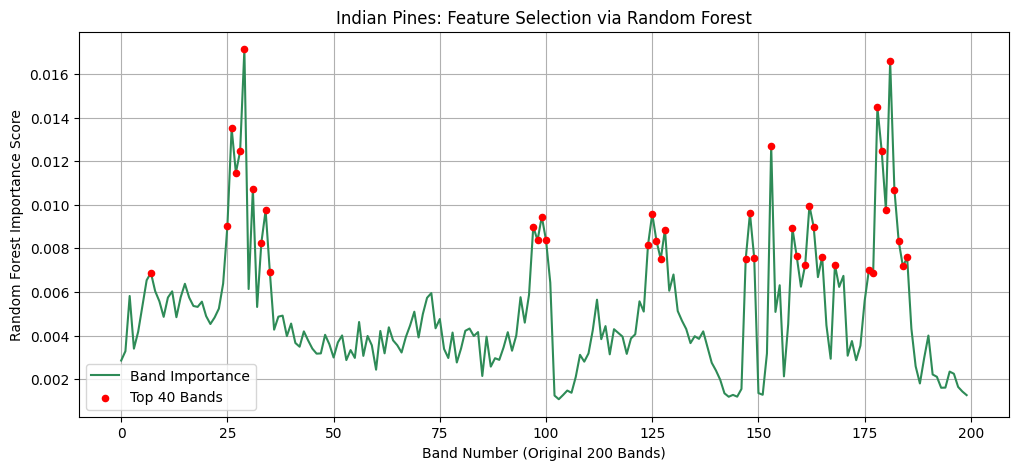

In [13]:
# Plot the Results
plt.figure(figsize=(12, 5))

# Plot all band importances as a line
plt.plot(range(c), importances, color='seagreen', linewidth=1.5, label='Band Importance')

# Put red dots on the top 40 most important bands
plt.scatter(top_indices, importances[top_indices], color='red', s=20, zorder=5, label=f'Top {num_top_bands} Bands')

plt.xlabel('Band Number (Original 200 Bands)')
plt.ylabel('Random Forest Importance Score')
plt.title('Indian Pines: Feature Selection via Random Forest')
plt.grid(True)
plt.legend()
plt.show()

**X-axis Band Number:** all the bands
- Bands near 0: There are the visible light bands (Blue, Green, Red)
- Bands in the middle (40-100): This is the Near-Infrared (NIR) region, which tells us about the physical cell structure of the leaves.
- Bands on the right (100-200): This is the Shortwave Infrared (SWIR) region, which is highly sensitive to the water content and dry matter inside the plants.

**Y-axis Random forest importance score:** it tells you exactly how much predictive power a specific band has.
How it is calculated: When the Random Forest builds its decision trees to figure out if a pixel is Corn, Soybean, or Alfalfa, it tests every single band.
- If looking at Band 30 easily splits the data into the correct crop classes, the model gives Band 30 a high score.
- If looking at Band 110 gives the model no useful information (maybe because all crops look the exact same in that wavelength, or it's just atmospheric noise), the model gives it a score near zero.

**How to read the whole picture**
Look at the massive spikes (the red dots) around Bands 25-35 and Bands 180-190.

This graph is telling you that you don't need all 200 bands to classify the crops in Indiana. The chemical and physical differences between a Corn field and a Soybean field are almost entirely visible in those specific, high-scoring wavelength clusters. The long "valleys" (like between bands 40 and 90) are basically dead weight for this specific classification task.
By keeping only the bands with the red dots, you throw away the dead weight while keeping the physical wavelengths that actually define the crops.


In [14]:
# Print the results for your report
# Sort top indices descending (most important first)
top_10 = np.argsort(importances)[-10:][::-1]
print(f"If you had to pick only the Top 10 most important bands, they are: {top_10}")

# To actually CREATE your reduced dataset using these physical bands:
X_selected = data[:, :, top_indices]
print(f"\nNew Data Shape using only selected bands: {X_selected.shape}")

If you had to pick only the Top 10 most important bands, they are: [ 29 181 178  26 153 179  28  27  31 182]

New Data Shape using only selected bands: (145, 145, 40)
